# t-test


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../05-data_cleaning/data/nls97.csv")
df.head()

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
1,100139,Male,9,1983,12.0,Married,2.0,0.0,120000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
2,100284,Male,11,1984,7.0,Never-married,1.0,0.0,58000.0,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
3,100292,Male,4,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,NaN,NaN,NaN,NaN
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled


## One-sample t-test

- Question: Is the average income different from \$50,000?
- Hypotheses:
    - Null hypothesis ($H_0$): $\mu=50000$
    - Alternative hypothesis ($H_1$): $\mu \neq 50000$ (two-side testing)

We are testing whether the sample mean differs from a known benchmark. Two-sided means we care about both higher or lower

In [3]:
income = df["wageincome"].dropna()

In [31]:
from scipy import stats

t_stat, p_value = stats.ttest_1samp(a=income, popmean=50000)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: mean income is significantly different from $50,000")
else:
    print("Fail to reject H0: no significant difference")

t-statistic: -0.917336028341287
p-value: 0.35901004585800356
Fail to reject H0: no significant difference


## Two-Sample t-test (Independent)
Question: Do men and women have different average incomes?

Hypothesis:
- Null hypothesis ($H_0$): $\mu_{male}=\mu_{female}$
- Alternative hypothesis ($H_1$): $\mu_{male}\neq\mu_{female}$

This compares two group means. Welch test is safer because it does not assume equal variance

<Axes: xlabel='wageincome', ylabel='Density'>

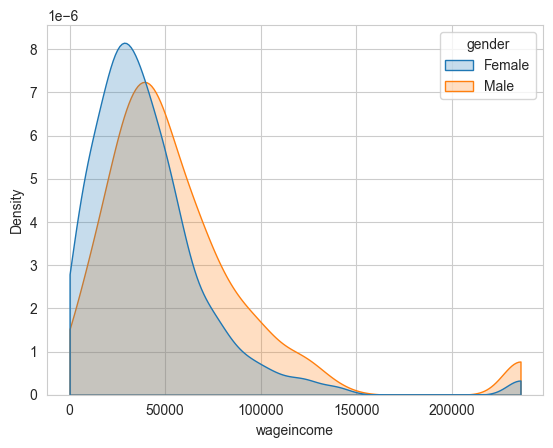

In [21]:
# We can inspect the income visually first
sns.kdeplot(data=df, x='wageincome', hue='gender', fill=True, cut=0)

In [ ]:
# split groups
male_income = df[df["gender"] == "Male"]["wageincome"].dropna()
female_income = df[df["gender"] == "Female"]["wageincome"].dropna()

In [32]:
# run t-test. Set equal_var = False to perform Welch's t-test, which compares the means of two independent samples without assuming their variances are equal. This approach is more robust than Student's t-test for unequal variances or different sample sizes, often providing more reliable results in real-world data analysis

t_stat, p_value = stats.ttest_ind(
    a=male_income,
    b=female_income,
    equal_var=False  # Welch’s t-test
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 14.346106548890676
p-value: 9.509106293352691e-46


In [10]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: income differs by gender")
else:
    print("Fail to reject H0: no significant difference")

Reject H0: income differs by gender


## One-Sided Test (Nice Extension)
Example: Are male incomes higher than female incomes?

Hypotheses:
- $H_0$: $\mu_{male} \ge \mu_{female}$
- $H_1$: $\mu_{male} > \mu_{female}$

Using the `alternative` parameter. It can take:
- `less`: when the alternative hypothesis (H1) is a < b
- `greater`: when the alternative hypothesis (H1) is a > b

In [29]:
t_stat, p_value_two_sided = stats.ttest_ind(
    a=male_income,
    b=female_income,
    alternative="greater",
    equal_var=False
)

print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_two_sided)


t-statistic: 14.346106548890676
one-sided p-value: 4.754553146676346e-46


In [30]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: males' income greater than females")
else:
    print("Fail to reject H0: males' income less than females")

Reject H0: males' income greater than females
